In [2]:
import numpy as np
from matplotlib import pyplot as plt

In [3]:
np.random.seed(52)

Task 1. Simulate a path of the Wiener process. Number of end-points of the grid including $T$ is $N=100$, length of the interval $[0, T]$ in time units is 1, time increment is $\Delta = T/N$. Plot the path.

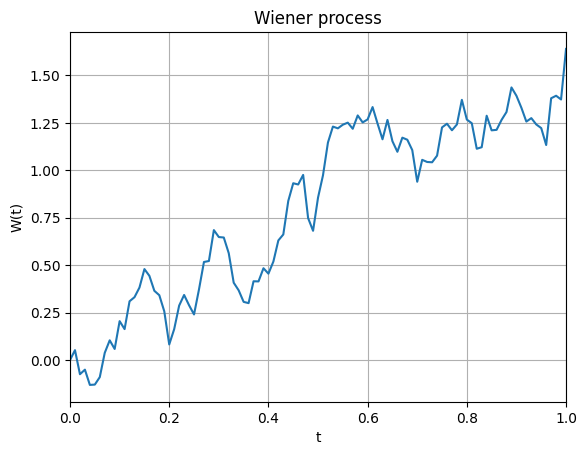

In [4]:
def WienerRandomValue(t):
    return np.sqrt(t) * np.random.normal(0, 1)


def WienerProcess(N, T):
    t_data = np.linspace(0, T, N + 1)
    w_data = np.zeros(N + 1)
    dt = T/N
    for i in range(1, N + 1):
        w_data[i] = w_data[i - 1] + WienerRandomValue(dt)
    return t_data, w_data

N = 100
T = 1
t_data, w_data = WienerProcess(N, T)

plt.plot(t_data, w_data)
plt.xlabel("t")
plt.ylabel("W(t)")
plt.xlim(0.0, T)
plt.title("Wiener process")
plt.grid(True)
plt.show()

Task 2. Using the random walk algorithm simulate three paths of the Wiener process as the limit of a random walk for different $n=10, 100, 1000$. Plot the paths in one figure, add the legend.

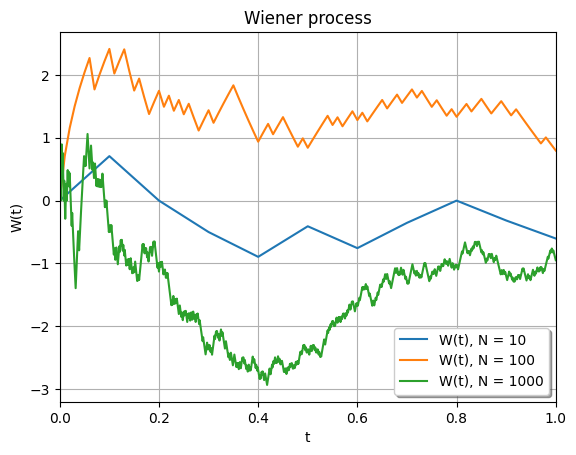

In [5]:
def RandomValueP(p):
    assert p > 0.0 and p < 1.0, '0 < p < 1'

    rand = np.random.uniform(0, 1)
    if rand <= p:
        return 1
    else:
        return -1

def RandomWalk(p, N):
    t_data = np.linspace(0, 1, N + 1)
    w_data = np.zeros(N + 1)
    for i in range(1, N + 1):
        w_data[i] = w_data[i - 1] * np.sqrt(i / (i + 1)) + RandomValueP(p) / np.sqrt(i + 1)
    return t_data, w_data

p = 0.5
N = [10, 100, 1000]
for k in N:
    t_data, w_data = RandomWalk(p, k)
    plt.plot(t_data, w_data, label = f"W(t), N = {k}")

plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlim(0.0, 1.0)
plt.xlabel("t")
plt.ylabel("W(t)")
plt.title("Wiener process")
plt.grid(True)
plt.show()

Task 3. Using the the Karhunen-Loeve expansion simulate three paths of the Wiener process with
$n = 10, 50, 100$ terms. Plot the paths in one figure, add legends.

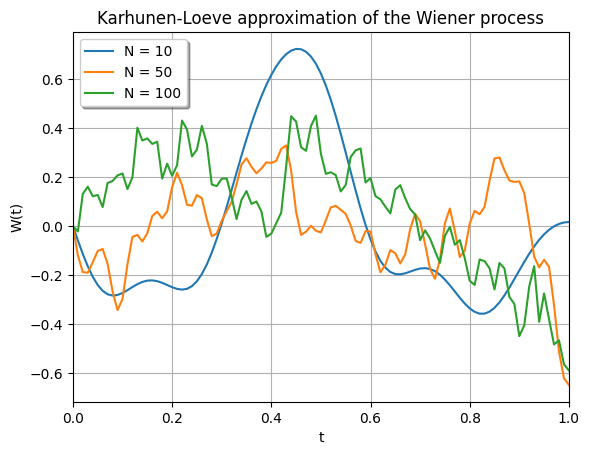

In [6]:
def phi(k, t, T):
    return 2 * np.sqrt(2 * T) / np.pi / (2 * k + 1) * np.sin((2 * k + 1) * np.pi * t / (2 * T))

def KarhunenLoeveApprox(T, Nt, Nz):
    z_data = np.random.normal(0, 1, size = Nz)
    t_data = np.linspace(0, T, Nt + 1)
    k = np.arange(0, len(z_data)) + 1
    w_data = np.zeros(Nt + 1)
    for i in range(0, Nt + 1):
        phi_data = phi(k, t_data[i], T)
        w_data[i] = np.dot(z_data, phi_data)
    return t_data, w_data

T = 1
Nt = 100
Nz = [10, 50, 100]

for k in Nz:
    t_data, w_data = KarhunenLoeveApprox(T, Nt, k)
    plt.plot(t_data, w_data, label = f'N = {k}')

plt.legend(loc = 'upper left', fancybox = True, shadow = True)
plt.xlim(0.0, 1.0)
plt.xlabel("t")
plt.ylabel("W(t)")
plt.title("Karhunen-Loeve approximation of the Wiener process")
plt.grid(True)
plt.show()

Task 4. Plot a trajectory of the geometric Brownian motion obtained from the simulation of the path of the Wiener process, $r=1$ (interest rate) and $\sigma = 0.5$ (volatility).

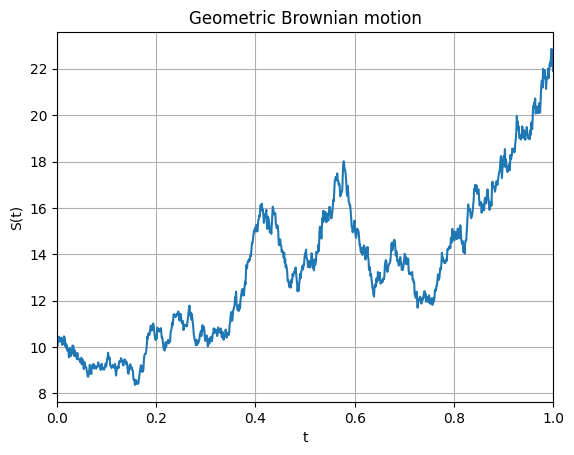

In [7]:
def GeometricBrownianMotion(S0, r, sigma, T):
    Nt = 1000
    t_data = np.linspace(0, T, Nt + 1)
    s_data = np.zeros(Nt + 1)
    s_data[0] = S0
    dt = T / Nt
    for i in range(1, Nt + 1):
        s_data[i] = s_data[i-1] * np.exp((r - sigma**2 / 2)* dt + sigma * WienerRandomValue(dt))
    return t_data, s_data

S0 = 10
r = 1
sigma = 0.5
T = 1

t_data, s_data = GeometricBrownianMotion(S0, r, sigma, T)
plt.plot(t_data, s_data)
plt.xlim(0.0, 1.0)
plt.xlabel("t")
plt.ylabel("S(t)")
plt.title("Geometric Brownian motion")
plt.grid(True)
plt.show()

Task 5. Plot a trajectory of the the Brownian bridge starting at $x$ at time $0$ and terminating its run at $y =-1$ at time $T$ obtained from the simulation of the path of the Wiener process. Add markers for start and end points.

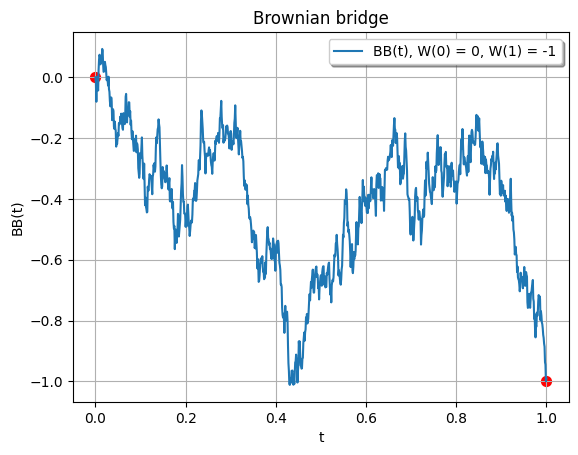

In [8]:
def BrownianBridge(x, y, t0, T):
    Nt = 1000
    t_data, w_data = WienerProcess(Nt, T)
    dt = T/Nt
    bb_data = np.zeros(Nt + 1)
    for i in range(0, Nt + 1):
        bb_data[i] = x + w_data[i] - (t_data[i] - t0) / (T - t0) * (w_data[Nt - 1] - y + x)
    return t_data, bb_data

x = 0
y = -1
t0 = 0
T = 1
t_data, bb_data = BrownianBridge(x, y, t0, T)

plt.plot(t_data, bb_data, label = f"BB(t), W({t0}) = {x}, W({T}) = {y}")
plt.scatter ( t0, x, color = "red", s = 50)
plt.scatter ( T, y, color = "red", s = 50)
plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("BB(t)")
plt.title("Brownian bridge")
plt.grid(True)
plt.show()

# Exercises

Exercise 1. Let us consider a random walk $X = (X_n)_{n \geq 0}$:
$$
X_n = \sum_{k=1}^n \xi_k, \quad \xi_k =
\begin{cases}
1, &\text{with probability $\frac12$}; \\
-1, &\text{with probability $\frac12$}.
\end{cases}
$$
$$
\mathbb{E}\xi_k = 0, \quad \mathrm{Var}\, \xi_k = 1.
$$

Plot $(X_{t_i})_{t_i = \frac{i}{n}}$ so that $t_i$ takes values in $[0,\, 1]$.

In [9]:
def RandomWalk(N, p=[0.5, 0.5]):
    # Генерируем случайные шаги
    xi = np.random.choice([-1, 1], size=N, p=p)

    # Вычисляем случайное блуждание
    X = np.cumsum(xi)  # Кумулятивная сумма шагов

    # Добавляем начальную позицию (0)
    X = np.insert(X, 0, 0)  # Добавляем X_0 = 0 в начало

    # Создаем массив t
    t = np.linspace(0, 1, N + 1)  # n + 1 точек для t_i

    # Строим график
    plt.figure(figsize=(10, 5))
    plt.plot(t, X, marker='o', linestyle='-')
    plt.title('Random Walk')
    plt.xlabel('t')
    plt.ylabel('$X_n$')
    plt.grid()
    plt.show()

Exercise 2. Let $H = (H_n)_{n \geq 1}$ be the player's bet at the $n$-th step, i.e. his winnings at this step are equal to $H_n (X_n - X_{n-1}) = H_n \Delta X_n$.

Plot an accumulated winnings of player $Y_n$ at step $n \geq 1$.


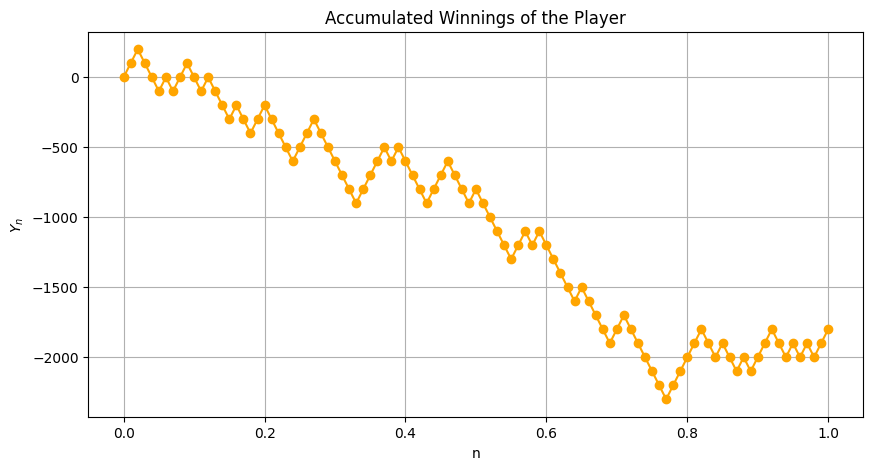

In [10]:
def random_walk_with_bets(n, H):
    # Генерируем случайные шаги
    xi = np.random.choice([-1, 1], size=n, p=[0.5, 0.5])

    # Вычисляем случайное блуждание
    X = np.cumsum(xi)

    # Добавляем начальную позицию (0)
    X = np.insert(X, 0, 0)  # Добавляем X_0 = 0 в начало

    # Вычисляем накопленные выигрыши
    Y = np.zeros(n + 1)  # Начинаем с 0
    for i in range(1, n + 1):
        Y[i] = Y[i - 1] + H * (X[i] - X[i - 1])  # Y_n = Y_{n-1} + H * ΔX_n

    # Создаем массив t
    t = np.linspace(0, 1, n + 1)  # n + 1 точек для t_i

    # Строим график накопленных выигрышей
    plt.figure(figsize=(10, 5))
    plt.plot(t, Y, marker='o', linestyle='-', color='orange')
    plt.title('Accumulated Winnings of the Player')
    plt.xlabel('n')
    plt.ylabel('$Y_n$')
    plt.grid()
    plt.show()

# Пример вызова функции с n = 100 и H = 1
random_walk_with_bets(100, H=100)

# Задачи

Задача 1. Квадратичная вариация (Раздел 1.1.2)

Для траектории винеровского процесса при $T=1$ и разного числа интервалов разбиения $\{10,100,1000,10000\}$:

1. Вычислите сумму квадратов приращений $$ S_n= ∑_{k=0}^{n−1}​ ∣W(t_{k+1} )−W(t_k​ )∣^2.$$

2. Постройте график зависимости суммы $S_n$ от числа интервалов разбиения (столбчатую диаграмму).

3. Сделайте выводы.

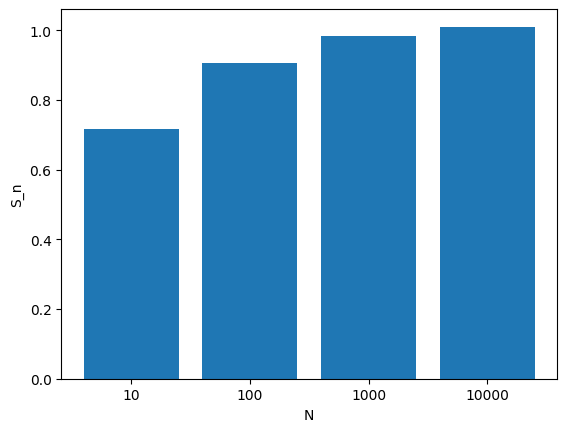

In [11]:
np.random.seed(52)
def WienerRandomValue(t):
    return np.sqrt(t) * np.random.normal(0, 1)


def WienerProcess(N, T):
    t_data = np.linspace(0, T, N + 1)
    w_data = np.zeros(N + 1)
    dt = T/N
    for i in range(1, N + 1):
        w_data[i] = w_data[i - 1] + WienerRandomValue(dt)
    return t_data, w_data

N = [10,100,1000,10000]
T = 1.0
Sn = []
for j in N:
  t_data, w_data = WienerProcess(j, T)
  inc = np.diff(w_data)
  sum_sn = np.sum(inc**2)
  Sn.append(sum_sn)
plt.bar(range(len(N)), Sn, tick_label=N)
plt.xlabel('N')
plt.ylabel('S_n')
plt.show()


Задача 2. Эмпирическая ковариационная функция (Раздел 1.1.3)

Для винеровского процесса теоретическая ковариация между состояниями в моменты времени $s$ и $t$ равна $\min(s,t)$.

1. Сгенерируйте ансамбль из 500 траекторий винеровского процесса.

2. Вычислите выборочную ковариацию между точками $t=0.5$ и $t=T$ и сравните полученное число с теоретическим значением $0.5$.

3. Сделайте выводы.

In [12]:
np.random.seed(52)
T = 1.0
t = 0.5
N = 1000
M = 500

idx_half = int(t * N)

w_half = []
w_one = []

for i in range(M):
    t_data, w_data = WienerProcess(N, T)
    w_half.append(w_data[idx_half])
    w_one.append(w_data[-1])

cov_res = np.cov(w_half, w_one)[0,1]
print(cov_res)

0.4445502163427824


Задача 3. Тестирование мартингального свойства (Раздел 1.1.5)

1. Сгенерируйте ансамбль из 500 траекторий винеровского процесса.

2. Выберите фиксированный момент времени $s=0.4$.

3. Для всех сгенерированных траекторий, проходящих через определенный узкий диапазон значений в момент $s$, вычислите среднее арифметическое их значений в финальный момент $T$.

4. Сравните полученное среднее арифметическое со значением процесса в момент $s$.

5. Сделайте выводы. Проанализовать как диапозон влияет на результат.

In [13]:
np.random.seed(52)
T = 1.0
s = 0.4
N = 1000
M = 500

idx = int(s * N)

w_s = []
w_one = []

for i in range(M):
    t_data, w_data = WienerProcess(N, T)
    w_s.append(w_data[idx])
    w_one.append(w_data[-1])

w_s = np.array(w_s)
w_one = np.array(w_one)
x0 = 0.5
eps_list = [0.5, 0.2, 0.1, 0.05, 0.02, 0.01]

print("epsilon\tcount\tmean_w(1)\tdiff")
for eps in eps_list:
    mask = (w_s >= x0 - eps) & (w_s <= x0 + eps)
    count = np.sum(mask)
    if count > 0:
        mean_val = np.mean(w_one[mask])
        print(f"{eps}\t{count}\t{mean_val:.4f}\t{mean_val - x0:.4f}")
    else:
        print(f"{eps}\t0\t-\t-")

epsilon	count	mean_w(1)	diff
0.5	224	0.3003	-0.1997
0.2	89	0.3044	-0.1956
0.1	49	0.2846	-0.2154
0.05	21	0.1215	-0.3785
0.02	8	0.3553	-0.1447
0.01	3	0.4255	-0.0745


Задача 4. Анализ независимости приращений (Раздел 1.2)

1. Выберите два непересекающихся интервала $[t_1, t_2​]$ и $[t_3, t_4​]$.
2. Сгенерируйте $M$ траекторий и вычислите приращения
$ΔW_1 =W(t_2)−W(t_1)$ и $ΔW_2 =W(t_4)−W(t_3)$.

3. Постройте диаграмму рассеяния (scatter plot) для $(ΔW_1, ΔW_2)$ и вычислите коэффициент корреляции.

4. Сравните полученное значение с нулем и сделайте выводы.

Corr 0.0895


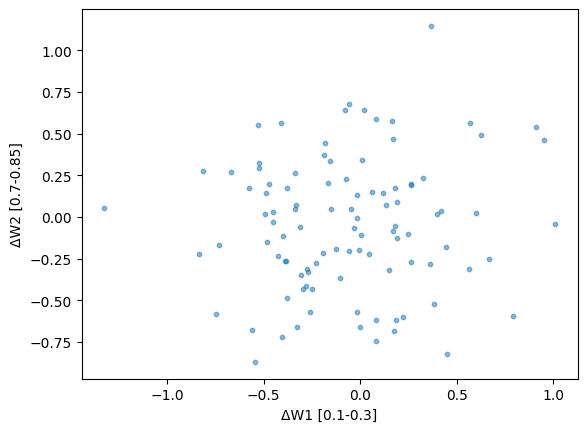

In [14]:
np.random.seed(52)
t1, t2, t3, t4 = 0.1, 0.3, 0.7, 0.85
T=1.0
M = 100
N=1000

idx1, idx2, idx3, idx4 = int(t1*N), int(t2*N), int(t3*N), int(t4*N)

dW1, dW2 = [], []
for _ in range(M):
    t_data, w_data = WienerProcess(N, T)
    dW1.append(w_data[idx2] - w_data[idx1])
    dW2.append(w_data[idx4] - w_data[idx3])

dW1, dW2 = np.array(dW1), np.array(dW2)
corr = np.corrcoef(dW1, dW2)[0, 1]

print(f"Corr {corr:.4f}")

plt.scatter(dW1, dW2, alpha=0.5, s=10)
plt.xlabel(f"ΔW1 [{t1}-{t2}]")
plt.ylabel(f"ΔW2 [{t3}-{t4}]")
plt.show()

Задача 5. Точность разложения Карунена-Лоэва (Раздел 1.2.3)

1. Реализуйте аппроксимацию винеровской траектории, используя $n=10, 100, 1000$ слагаемых.
2. Рассчитайте среднеквадратичную ошибку между прямой симуляцией и аппроксимацией Карунена-Лоэва.

3. Постройте график зависимости ошибки при увеличении числа членов ряда $n$.
4. Сделайте выводы.


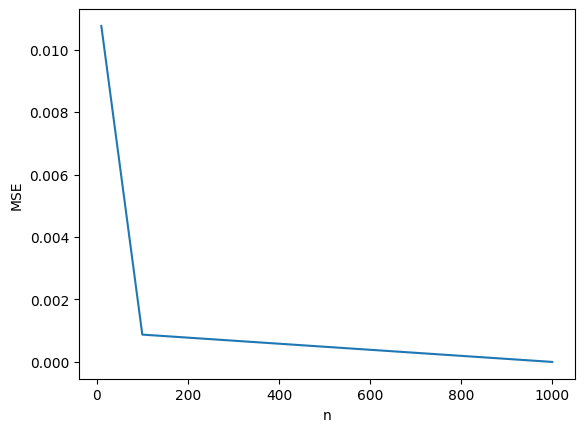

In [15]:
np.random.seed(52)

def kl_approximation(t, T, n, z):
    w_kl = np.zeros_like(t)
    for i in range(n):
        phi_i = (2 * np.sqrt(2*T)) / ((2*i + 1) * np.pi) * np.sin((2*i + 1) * np.pi * t / (2*T))
        w_kl += z[i] * phi_i
    return w_kl


N= 1000
T = 1.0
t_kl = np.linspace(0, T, N + 1)
z = np.random.normal(0, 1, 1000)
w_reference = kl_approximation(t_kl, T, 1000, z)

n_list = [10, 100, 1000]
mse_list = []
for n in n_list:
    w_kl = kl_approximation(t_kl, T, n, z[:n])
    mse = np.mean((w_reference - w_kl)**2)
    mse_list.append(mse)

plt.plot(n_list, mse_list)
plt.xlabel('n')
plt.ylabel('MSE')
plt.show()